# 1-3. 분포 통계량

- 백분위수, 사분위수, 왜도, 첨도를 계산해본다.

In [1]:
import numpy as np
from scipy import stats
import pandas as pd

## 1. 백분위수와 사분위수 계산

In [3]:
# 1부터 11까지의 정수 배열 생성
x = np.arange(1, 12, 1)

print(x)

[ 1  2  3  4  5  6  7  8  9 10 11]


### 1-1. 20백분위수 계산

percentile은 0부터 100까지의 숫자를 사용한다.
quantile은 0부터 1까지의 숫자를 사용한다.

20%와 0.2는 같은 위치다.

In [4]:
# 20백분위수: 하위 20% 지점의 값
print(np.percentile(x, 20))

# 0.2 분위수: 전체를 1로 봤을 때 하위 20% 지점의 값
print(np.quantile(x, 0.2))

3.0
3.0


### 1-2. 1사분위수(Q1) 계산

1사분위수는 정렬한 데이터의 25% 지점 값이다.
25%와 0.25는 같은 위치다.

In [5]:
# 25백분위수 = 1사분위수(Q1)
print(np.percentile(x, 25))

# 0.25 분위수 = 1사분위수(Q1)
print(np.quantile(x, 0.25))

3.5
3.5


## 2. 왜도 계산

왜도는 데이터 분포의 꼬리가 어느 방향으로 긴지 나타내는 값이다.

- 양의 왜도: 오른쪽 꼬리가 김
- 왜도 0: 좌우 대칭
- 음의 왜도: 왼쪽 꼬리가 김

In [7]:
from matplotlib import pyplot as plt

# 숫자 1이 30개, 2가 20개, ...인 데이터
# 오른쪽 꼬리가 긴 분포 → 양의 왜도
x1 = [1] * 30 + [2] * 20 + [3] * 20 + [4] * 15 + [5] * 15

# 가운데 값 3이 가장 많은 대칭 분포
x2 = [1] * 15 + [2] * 20 + [3] * 30 + [4] * 20 + [5] * 15

# 왼쪽 꼬리가 긴 분포 → 음의 왜도
x3 = [1] * 15 + [2] * 15 + [3] * 20 + [4] * 20 + [5] * 30

In [8]:
# x1의 앞에서 5개만 확인
print(x1[:5])

# 각 숫자가 몇 개씩 들어 있는지 확인
print(pd.Series(x1).value_counts(sort=False))

[1, 1, 1, 1, 1]
1    30
2    20
3    20
4    15
5    15
Name: count, dtype: int64


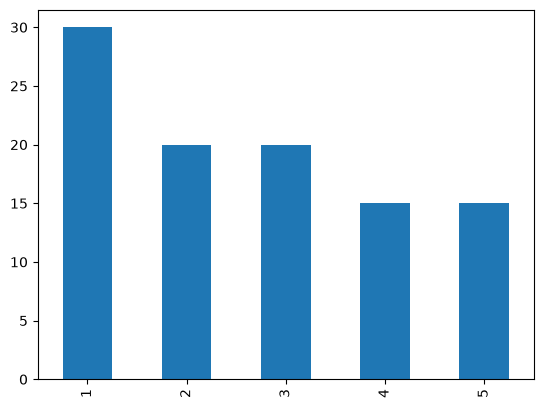

In [9]:
# 각 값의 빈도를 막대그래프로 표시
pd.Series(x1).value_counts(sort=False).plot(kind="bar")

plt.show()

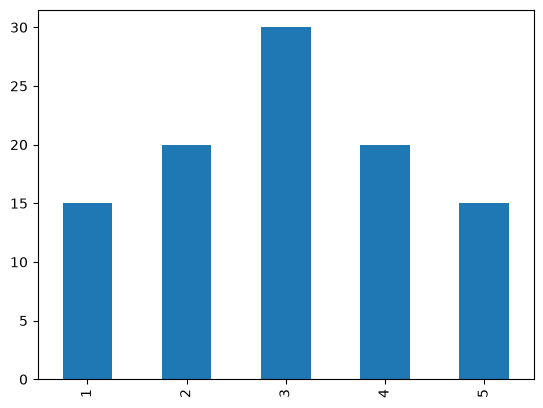

In [10]:
# x2의 빈도를 막대그래프로 표시
pd.Series(x2).value_counts(sort=False).plot(kind="bar")

plt.show()

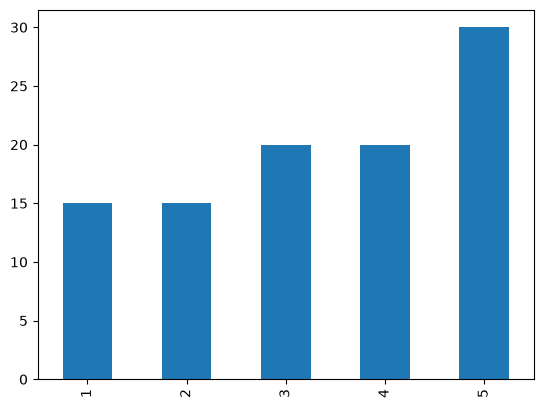

In [11]:
# x3의 빈도를 막대그래프로 표시
pd.Series(x3).value_counts(sort=False).plot(kind="bar")

plt.show()

### 2-1. 왜도 값 계산

왜도 값의 부호로 분포의 꼬리 방향을 확인한다.

In [12]:
print("x1 - 오른쪽 꼬리, 양의 왜도:", stats.skew(x1))
print("x2 - 대칭, 왜도 0:", stats.skew(x2))
print("x3 - 왼쪽 꼬리, 음의 왜도:", stats.skew(x3))

x1 - 오른쪽 꼬리, 양의 왜도: 0.319280100848636
x2 - 대칭, 왜도 0: 0.0
x3 - 왼쪽 꼬리, 음의 왜도: -0.31928010084863595


## 3. 첨도 계산

첨도는 데이터 분포가 가운데에 얼마나 모여 있는지와 양끝의 극단값 경향을 나타내는 값이다.

이 예제에서는 가운데 값인 `3`이 많을수록 그래프가 더 뾰족해진다.

In [13]:
# 모든 값의 개수가 같음 → 평평한 분포
x1 = [1] * 20 + [2] * 20 + [3] * 20 + [4] * 20 + [5] * 20

# 가운데 값 3이 조금 더 많음
x2 = [1] * 10 + [2] * 20 + [3] * 40 + [4] * 20 + [5] * 10

# 가운데 값 3이 매우 많음 → 가장 뾰족한 분포
x3 = [1] * 5 + [2] * 15 + [3] * 60 + [4] * 15 + [5] * 5

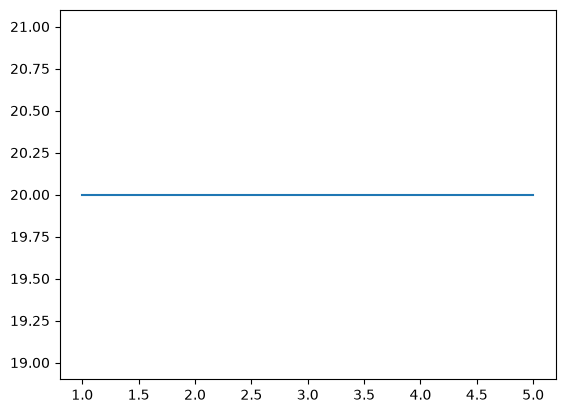

In [14]:
# x1: 모든 값의 개수가 같아서 평평한 분포
pd.Series(x1).value_counts(sort=False).plot(kind="line")

plt.show()

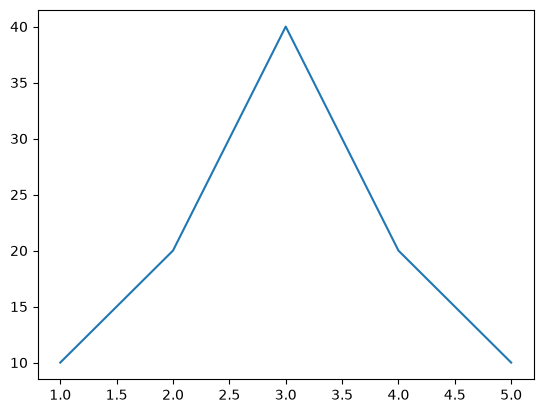

In [15]:
# x2: 가운데 값 3이 더 많아서 조금 뾰족한 분포
pd.Series(x2).value_counts(sort=False).plot(kind="line")

plt.show()

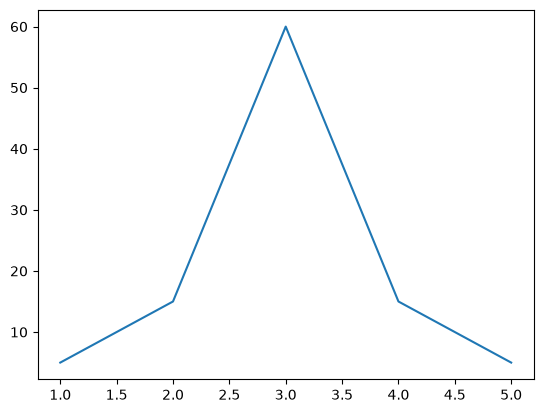

In [17]:
# x3: 가운데 값 3이 매우 많아서 가장 뾰족한 분포
pd.Series(x3).value_counts(sort=False).plot(kind="line")

plt.show()

In [18]:
# scipy의 kurtosis() 함수로 첨도 계산
print("평평한 분포의 첨도:", stats.kurtosis(x1))
print("조금 뾰족한 분포의 첨도:", stats.kurtosis(x2))
print("매우 뾰족한 분포의 첨도:", stats.kurtosis(x3))

평평한 분포의 첨도: -1.3
조금 뾰족한 분포의 첨도: -0.5
매우 뾰족한 분포의 첨도: 0.8775510204081636


### 3-1. 첨도 결과 해석

`stats.kurtosis()`는 정규분포를 기준값 `0`으로 본다.

- 첨도 < 0: 상대적으로 평평한 분포
- 첨도 = 0: 정규분포와 비슷한 수준
- 첨도 > 0: 상대적으로 가운데가 뾰족하고 극단값 경향이 큰 분포

이번 예제에서는 `x1 → x2 → x3` 순서로 가운데 값 `3`에 더 많이 모이므로,
첨도 값도 `-1.3 → -0.5 → 0.88`처럼 커진다.

In [19]:
# Pandas Series의 kurtosis() 메서드로 첨도 계산
print("평평한 분포의 첨도:", pd.Series(x1).kurtosis())
print("조금 뾰족한 분포의 첨도:", pd.Series(x2).kurtosis())
print("매우 뾰족한 분포의 첨도:", pd.Series(x3).kurtosis())

평평한 분포의 첨도: -1.3049337260677465
조금 뾰족한 분포의 첨도: -0.46344414054281513
매우 뾰족한 분포의 첨도: 0.9855494059605747


### 3-2. SciPy와 Pandas 첨도 값이 다른 이유

`stats.kurtosis()`와 `Series.kurtosis()`는 첨도를 계산할 때 사용하는 보정 방식이 조금 다르다.

그래서 결과 숫자는 약간 다를 수 있다.
하지만 이번 예제처럼 `x1 → x2 → x3`으로 갈수록 첨도가 커진다는 해석은 동일하다.

## 4. 핵심 정리

- 백분위수: 정렬한 데이터에서 특정 비율 위치의 값
- 사분위수: 데이터를 4등분한 위치의 값
  - Q1: 25%, Q2: 50%, Q3: 75%
- 왜도: 꼬리가 긴 방향을 확인
  - 양수: 오른쪽 꼬리가 김
  - 음수: 왼쪽 꼬리가 김
- 첨도: 분포의 평평함·뾰족함과 극단값 경향을 확인
  - 음수: 상대적으로 평평함
  - 양수: 상대적으로 뾰족함